# Exp 11: Custom CNN + Bi-GRU + Bidirectional Cross-Attention

**Goal:** Replace self-attention over a joint sequence (Exp 10) with explicit bidirectional cross-attention between image and text representations.

**Architecture:**
```
Image → CNN → patch tokens   [B, 196, 256]  ──→ Cross-Attn (Q=img, KV=txt) → img_out
                                            ↕  (bidirectional)
Text  → Bi-GRU → hidden states [B, seq, 256] ──→ Cross-Attn (Q=txt, KV=img) → txt_out

→ GAP(img_out) || Mean(txt_out) → Concat → FCNN → 1
```

**Key difference from Exp 10:**
- Exp 10 self-attention: every token attends to every other token (same modality + cross)
- Exp 11 cross-attention: image patches attend ONLY to text tokens and vice versa. Explicit, directed cross-modal interaction.

**Why bidirectional?** Image→Text finds which words are relevant to each patch. Text→Image finds which patches are relevant to each word. Both directions together give a richer aligned representation.

In [ ]:
!pip install -q jsonlines

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import json, copy, os
import jsonlines
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub, shutil, os, sys
from pathlib import Path

# Download dataset to Colab SSD (much faster than Drive FUSE)
path = kagglehub.dataset_download("parthplc/facebook-hateful-meme-dataset")
print("Downloaded to:", path)

for root, dirs, files in os.walk(path):
    for f in files[:5]:
        print(os.path.join(root, f))

Using Colab cache for faster access to the 'facebook-hateful-meme-dataset' dataset.
Downloaded to: /kaggle/input/facebook-hateful-meme-dataset
/kaggle/input/facebook-hateful-meme-dataset/data/dev.jsonl
/kaggle/input/facebook-hateful-meme-dataset/data/test.jsonl
/kaggle/input/facebook-hateful-meme-dataset/data/README.md
/kaggle/input/facebook-hateful-meme-dataset/data/LICENSE.txt
/kaggle/input/facebook-hateful-meme-dataset/data/train.jsonl
/kaggle/input/facebook-hateful-meme-dataset/data/img/52691.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/37825.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/06781.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/49075.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/73516.png


In [ ]:
ROOT    = Path(path) / 'data'
IMG_DIR = ROOT / 'img'

RESULTS_DIR = 'content/results'
MODELS_DIR  = 'content/models'
OUTPUTS_DIR = 'content/outputs'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'ROOT   : {ROOT}')
print(f'IMG_DIR: {IMG_DIR}')

ROOT   : /kaggle/input/facebook-hateful-meme-dataset/data
IMG_DIR: /kaggle/input/facebook-hateful-meme-dataset/data/img


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Load Data & Vocab (from Exp 9)

In [ ]:
def load_jsonl(path):
    data = []
    with jsonlines.open(path) as reader:
        for item in reader: data.append(item)
    return data

train_data = load_jsonl(ROOT / 'train.jsonl')
dev_data   = load_jsonl(ROOT / 'dev.jsonl')

assert os.path.exists('content/results/vocab.json'), 'Run exp9 first to generate vocab.json!'
vocab_data = json.load(open('content/results/vocab.json'))
word2idx   = vocab_data['word2idx']
VOCAB_SIZE = vocab_data['vocab_size']
PAD_IDX    = vocab_data['pad_idx']
UNK_IDX    = vocab_data['unk_idx']
print(f'Train: {len(train_data)} | Dev: {len(dev_data)} | Vocab: {VOCAB_SIZE}')

Train: 8500 | Dev: 500 | Vocab: 5829


## 2. Dataset

In [ ]:
MAX_LEN  = 32
IMG_SIZE = 224
FEAT_DIM = 256

img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def simple_tokenize(text): return text.lower().split()

def encode_text(text, max_len=MAX_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids

class HatefulMemesDataset(Dataset):
    def __init__(self, data, img_dir, transform):
        self.data      = data
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        image   = Image.open(self.img_dir / item['img'].split('/')[-1]).convert('RGB')
        img_t   = self.transform(image)
        text_t  = torch.tensor(encode_text(item['text']), dtype=torch.long)
        txt_key_pad_mask = (text_t == PAD_IDX)  # for cross-attn key padding
        label   = torch.tensor(item['label'], dtype=torch.float32)
        return img_t, text_t, txt_key_pad_mask, label

BATCH_SIZE   = 32
train_ds     = HatefulMemesDataset(train_data, IMG_DIR, img_transform)
dev_ds       = HatefulMemesDataset(dev_data,   IMG_DIR, img_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_pos      = sum(d['label'] for d in train_data)
n_neg      = len(train_data) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')
print(f'pos_weight: {pos_weight.item():.3f}')

Train batches: 266 | Dev batches: 16
pos_weight: 1.787


## 3. Model — CNN + Bi-GRU + Bidirectional Cross-Attention

### CrossAttentionLayer
Uses `nn.MultiheadAttention` with **Q from one modality, K and V from the other**.
- `img→txt`: Q=image patches, KV=text hidden states → image features updated with text context
- `txt→img`: Q=text hidden states, KV=image patches → text features updated with image context

Both directions run in parallel then are fused. This is the core of models like ViLBERT and UNITER, here implemented from scratch without pretrained weights.

In [ ]:
class CNNPatchEncoder(nn.Module):
    def __init__(self, feat_dim=256):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64),
            conv_block(64, 128), conv_block(128, 256)
        )
        self.proj = nn.Linear(256, feat_dim)

    def forward(self, x):
        x = self.features(x)                   # [B, 256, 14, 14]
        x = x.flatten(2).transpose(1, 2)       # [B, 196, 256]
        return self.proj(x)                     # [B, 196, feat_dim]


class BiGRUEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 feat_dim=256, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.dropout   = nn.Dropout(dropout)
        self.proj      = nn.Linear(hidden_dim * 2, feat_dim)

    def forward(self, token_ids):
        emb     = self.dropout(self.embedding(token_ids))
        out, _  = self.gru(emb)
        return self.proj(self.dropout(out))      # [B, seq, feat_dim]


class BidirectionalCrossAttention(nn.Module):
    """
    Bidirectional cross-attention:
      img_out = CrossAttn(Q=img, KV=txt)  — image attends to text
      txt_out = CrossAttn(Q=txt, KV=img)  — text attends to image
    Both directions run independently then returned separately.
    """
    def __init__(self, feat_dim=256, nhead=8, dropout=0.1):
        super().__init__()
        self.img_to_txt_attn = nn.MultiheadAttention(
            embed_dim=feat_dim, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.txt_to_img_attn = nn.MultiheadAttention(
            embed_dim=feat_dim, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.img_norm = nn.LayerNorm(feat_dim)
        self.txt_norm = nn.LayerNorm(feat_dim)
        self.img_ffn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim * 4), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(feat_dim * 4, feat_dim)
        )
        self.txt_ffn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim * 4), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(feat_dim * 4, feat_dim)
        )
        self.img_ffn_norm = nn.LayerNorm(feat_dim)
        self.txt_ffn_norm = nn.LayerNorm(feat_dim)

    def forward(self, img_tokens, txt_tokens, txt_key_pad_mask=None):
        # img attends to txt
        img_attn, _ = self.img_to_txt_attn(
            query=img_tokens, key=txt_tokens, value=txt_tokens,
            key_padding_mask=txt_key_pad_mask
        )
        img_out = self.img_norm(img_tokens + img_attn)
        img_out = self.img_ffn_norm(img_out + self.img_ffn(img_out))

        # txt attends to img (no padding mask for img patches)
        txt_attn, _ = self.txt_to_img_attn(
            query=txt_tokens, key=img_tokens, value=img_tokens
        )
        txt_out = self.txt_norm(txt_tokens + txt_attn)
        txt_out = self.txt_ffn_norm(txt_out + self.txt_ffn(txt_out))

        return img_out, txt_out  # [B, 196, feat_dim], [B, seq, feat_dim]


class CNNBiGRUCrossAttn(nn.Module):
    def __init__(self, vocab_size, pad_idx, feat_dim=256,
                 nhead=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn_encoder = CNNPatchEncoder(feat_dim=feat_dim)
        self.gru_encoder = BiGRUEncoder(vocab_size, feat_dim=feat_dim,
                                         pad_idx=pad_idx, dropout=dropout)
        self.cross_attn_layers = nn.ModuleList([
            BidirectionalCrossAttention(feat_dim=feat_dim, nhead=nhead, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(feat_dim, feat_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(feat_dim // 2, 1)
        )

    def forward(self, images, token_ids, txt_key_pad_mask):
        img_tokens = self.cnn_encoder(images)          # [B, 196, feat_dim]
        txt_tokens = self.gru_encoder(token_ids)        # [B, seq, feat_dim]

        for layer in self.cross_attn_layers:
            img_tokens, txt_tokens = layer(img_tokens, txt_tokens, txt_key_pad_mask)

        img_pooled = img_tokens.mean(dim=1)            # [B, feat_dim]

        mask_float = (~txt_key_pad_mask).float().unsqueeze(-1)  # [B, seq, 1]
        txt_pooled = (txt_tokens * mask_float).sum(1) / mask_float.sum(1).clamp(min=1)

        fused = torch.cat([img_pooled, txt_pooled], dim=-1)  # [B, 2*feat_dim]
        return self.classifier(fused).squeeze(-1)


model = CNNBiGRUCrossAttn(vocab_size=VOCAB_SIZE, pad_idx=PAD_IDX).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')

Trainable params: 4,788,609


## 4. Optimizer & Scheduler

In [ ]:
EPOCHS    = 20
PATIENCE  = 5
LR        = 1e-4

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Epochs: {EPOCHS} | LR: {LR} | Patience: {PATIENCE}')

Epochs: 20 | LR: 0.0001 | Patience: 5


## 5. Training Loop

In [ ]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    for images, token_ids, txt_key_pad_mask, y in loader:
        images           = images.to(DEVICE)
        token_ids        = token_ids.to(DEVICE)
        txt_key_pad_mask = txt_key_pad_mask.to(DEVICE)
        y                = y.to(DEVICE)

        with autocast():
            logits = model(images, token_ids, txt_key_pad_mask)
            loss   = criterion(logits, y)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * len(y)
        all_probs.extend(torch.sigmoid(logits).detach().float().cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_dev_auc, best_state, patience_ctr = 0.0, None, 0

exp9_auc  = json.load(open('content/results/exp9.json'))['results']['dev_auc_roc']
exp10_auc = json.load(open('content/results/exp10.json'))['results']['dev_auc_roc']

print('Training: CNN + Bi-GRU + Bidirectional Cross-Attention (all from scratch)')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
    history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

    if dv_auc > best_dev_auc:
        best_dev_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0; flag = '  <- best'
    else:
        patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} Acc {tr_acc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

model.load_state_dict(best_state)
print(f'\nBest Dev AUC     : {best_dev_auc:.4f}')
print(f'Exp 9  (FCNN)    : {exp9_auc:.4f}')
print(f'Exp 10 (SelfAttn): {exp10_auc:.4f}')
print(f'Cross-attn delta vs Exp 10: {best_dev_auc - exp10_auc:+.4f}')

Training: CNN + Bi-GRU + Bidirectional Cross-Attention (all from scratch)
Ep 01 | Tr Loss 0.8851 AUC 0.5493 Acc 0.5405 | Dev Loss 0.9692 AUC 0.5058 Acc 0.5060  <- best
Ep 02 | Tr Loss 0.8708 AUC 0.5991 Acc 0.5836 | Dev Loss 0.9795 AUC 0.5181 Acc 0.5120  <- best
Ep 03 | Tr Loss 0.8521 AUC 0.6384 Acc 0.6072 | Dev Loss 0.9741 AUC 0.5385 Acc 0.5140  <- best
Ep 04 | Tr Loss 0.8319 AUC 0.6710 Acc 0.6320 | Dev Loss 1.0958 AUC 0.5678 Acc 0.5120  <- best
Ep 05 | Tr Loss 0.8120 AUC 0.6957 Acc 0.6505 | Dev Loss 1.0042 AUC 0.5304 Acc 0.5120  (patience 1/5)
Ep 06 | Tr Loss 0.7980 AUC 0.7130 Acc 0.6652 | Dev Loss 1.0176 AUC 0.5787 Acc 0.5580  <- best
Ep 07 | Tr Loss 0.7752 AUC 0.7340 Acc 0.6767 | Dev Loss 1.1682 AUC 0.5910 Acc 0.5540  <- best
Ep 08 | Tr Loss 0.7607 AUC 0.7492 Acc 0.6841 | Dev Loss 1.3092 AUC 0.6162 Acc 0.5460  <- best
Ep 09 | Tr Loss 0.7496 AUC 0.7591 Acc 0.6985 | Dev Loss 1.1692 AUC 0.6208 Acc 0.5780  <- best
Ep 10 | Tr Loss 0.7289 AUC 0.7743 Acc 0.7058 | Dev Loss 1.0636 AUC 0.6192

## 6. Training Curves

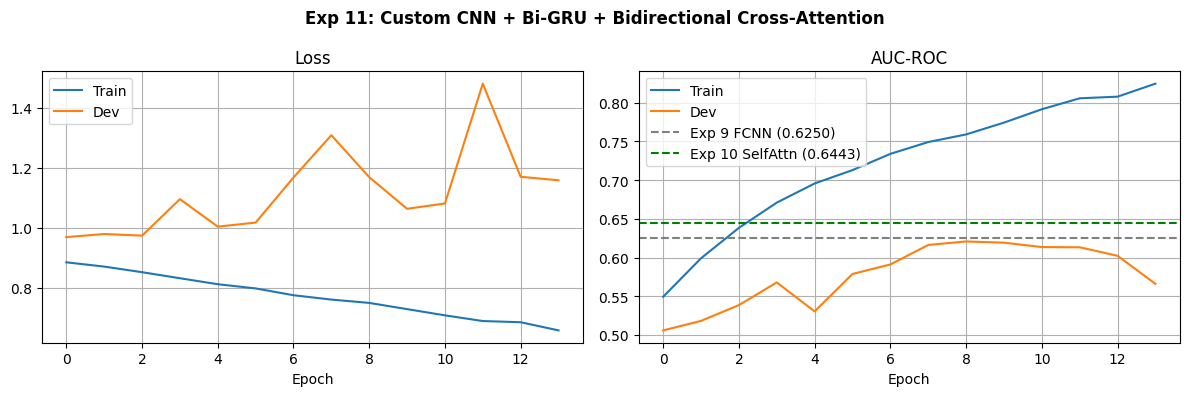

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['dev_loss'], label='Dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_auc'], label='Train'); axes[1].plot(history['dev_auc'], label='Dev')
axes[1].axhline(exp9_auc,  color='gray',  linestyle='--', label=f'Exp 9 FCNN ({exp9_auc:.4f})')
axes[1].axhline(exp10_auc, color='green', linestyle='--', label=f'Exp 10 SelfAttn ({exp10_auc:.4f})')
axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Exp 11: Custom CNN + Bi-GRU + Bidirectional Cross-Attention', fontweight='bold')
plt.tight_layout()
plt.savefig('content/outputs/11_training_curves.png', dpi=150)
plt.show()

## 7. Final Summary & Save

In [ ]:
_, dev_auc, dev_acc, dev_probs, dev_true = run_epoch(dev_loader, model, criterion)
dev_preds = (dev_probs >= 0.5).astype(int)
print('=' * 60)
print('EXP 11 — CNN + Bi-GRU + Bidirectional Cross-Attention | Dev Set')
print('=' * 60)
print(f'AUC-ROC  : {dev_auc:.4f}')
print(f'Accuracy : {dev_acc:.4f}')
print()
print(classification_report(dev_true, dev_preds, target_names=['Not Hateful', 'Hateful']))

print()
print('=' * 65)
print('CUSTOM ARCHITECTURE SUMMARY (Exp 9–11, no pretrained weights)')
print('=' * 65)
print(f'  Exp 9  — CNN + Bi-GRU + FCNN           : AUC = {exp9_auc:.4f}')
print(f'  Exp 10 — CNN + Bi-GRU + Self-Attention  : AUC = {exp10_auc:.4f}')
print(f'  Exp 11 — CNN + Bi-GRU + Cross-Attention : AUC = {dev_auc:.4f}')
best = max([(exp9_auc, 'FCNN'), (exp10_auc, 'Self-Attention'), (dev_auc, 'Cross-Attention')])
print(f'\n  Best custom architecture: {best[1]} (AUC = {best[0]:.4f})')

torch.save(best_state, 'content/models/11_cnn_bigru_cross_attn.pt')

exp11_out = {
    'experiment': '11_CNN_BiGRU_CrossAttention',
    'pipeline': 'CNN patches [196] + BiGRU hidden states [seq] -> BiDirectional CrossAttn (2 layers) -> pool -> concat -> FCNN',
    'pretrained': False,
    'results': {'dev_auc_roc': round(float(dev_auc), 4), 'dev_accuracy': round(float(dev_acc), 4)},
    'architecture': {
        'cnn': '4 conv blocks -> 196 patch tokens -> Linear(256)',
        'bigru': 'Embedding + BiGRU -> all hidden states -> Linear(256)',
        'cross_attention': '2x BidirectionalCrossAttn(d=256, nhead=8) — img->txt and txt->img',
        'classifier': 'GAP(img) || MeanPool(txt) -> concat -> Linear(256) -> Linear(128) -> Linear(1)'
    },
    'comparison': {
        'exp9_fcnn':        exp9_auc,
        'exp10_self_attn':  exp10_auc,
        'exp11_cross_attn': round(float(dev_auc), 4)
    }
}
with open('content/results/exp11.json', 'w') as f:
    json.dump(exp11_out, f, indent=2)

print('Model   -> content/models/11_cnn_bigru_cross_attn.pt')
print('Results -> content/results/exp11.json')
print(json.dumps(exp11_out, indent=2))

EXP 11 — CNN + Bi-GRU + Bidirectional Cross-Attention | Dev Set
AUC-ROC  : 0.6208
Accuracy : 0.5780

              precision    recall  f1-score   support

 Not Hateful       0.56      0.78      0.65       250
     Hateful       0.63      0.38      0.47       250

    accuracy                           0.58       500
   macro avg       0.59      0.58      0.56       500
weighted avg       0.59      0.58      0.56       500


CUSTOM ARCHITECTURE SUMMARY (Exp 9–11, no pretrained weights)
  Exp 9  — CNN + Bi-GRU + FCNN           : AUC = 0.6250
  Exp 10 — CNN + Bi-GRU + Self-Attention  : AUC = 0.6443
  Exp 11 — CNN + Bi-GRU + Cross-Attention : AUC = 0.6208

  Best custom architecture: Self-Attention (AUC = 0.6443)
Model   -> content/models/11_cnn_bigru_cross_attn.pt
Results -> content/results/exp11.json
{
  "experiment": "11_CNN_BiGRU_CrossAttention",
  "pipeline": "CNN patches [196] + BiGRU hidden states [seq] -> BiDirectional CrossAttn (2 layers) -> pool -> concat -> FCNN",
  "pretrained